# Rolling-Reference Binning — Prototype Test Notebook

Exercises `escape.storage.rollin_dev`, a **prototype** (not yet part of the public
`escape` API) for binning a large stack of images by a scan/target variable while
normalizing against a rolling window of reference shots — without ever reordering
the full lazy array (contrast with `Array.digitize`, which fancy-indexes the whole
array and can force a worker to materialize an entire bin's worth of scattered
chunks at once).

This notebook is meant as a scratchpad to poke at the module while it's still under
development. See the "Open issues" section at the bottom of `rollin_dev.py` for what
is and isn't settled — in particular, the rolling reference window currently resets
at every chunk boundary, which is expected to lose some events at chunk starts (see
section 4 below to see exactly how much, for your own parameters).


In [1]:
from _devpath import prepend_local_checkout_to_path
prepend_local_checkout_to_path()

In [2]:
import time

import numpy as np
import matplotlib.pyplot as plt
import dask.array as da
from dask import delayed

from escape.storage import rollin_dev as rd

## 1 — Correctness check on tiny synthetic data

Before trusting the dask pipeline, check `bin_running_ref` + `tree_merge` against a
plain-numpy ground truth on a small enough case to reason about by hand. Reference
events are excluded here (`n_ref_min=0`, i.e. no warm-up gating) so this cell isolates
*binning* correctness from the *rolling window* behavior covered in section 4.


In [3]:
np.random.seed(0)

n_events = 500
event_shape = (10, 10)
n_bins_total = 20
chunk_size = 25

data = np.random.rand(n_events, *event_shape)
weights = np.random.rand(n_events)
bins = np.random.randint(0, n_bins_total, n_events)
idop = np.ones(n_events, dtype=bool)   # every event is "signal" for this check
iref = np.zeros(n_events, dtype=bool)  # no rolling window in play (n_ref_min=0 below)

# ground truth: direct weighted sum per bin
expected = np.zeros((n_bins_total, *event_shape))
expected_n = np.zeros(n_bins_total)
for i in range(n_events):
    expected[bins[i]] += data[i] * weights[i]
    expected_n[bins[i]] += weights[i]

# same computation via bin_running_ref + tree_merge, chunked
partials = []
for start in range(0, n_events, chunk_size):
    sl = slice(start, start + chunk_size)
    partials.append(delayed(rd.bin_running_ref)(
        data[sl], idop[sl], iref[sl], bins[sl], weights[sl], n_refs=1, n_ref_min=0
    ))

merged = rd.tree_merge(partials, n_bins_total, event_shape, arity=4)
data_out, n_out, _sumsq_out, _raw_out = merged.compute()

print("matches direct sum (data):", np.allclose(data_out, expected))
print("matches direct sum (n):  ", np.allclose(n_out, expected_n))

matches direct sum (data): True
matches direct sum (n):   True


## 2 — `cmp_type`: comparing the signal to its rolling reference

`bin_running_ref` originally only used the reference window as a "warm-up" gate —
the collected reference frames were never actually used in the computation. It now
takes `cmp_type="none"|"difference"|"ratio"` (matching the same convention as
`ArrayTools.compare_to_reference`) and `ref_weighted=True/False` for how `ref_mean`
itself is computed. This cell constructs data with known reference and signal levels
so the effect is checkable by eye: reference frames sit around `ref_level`, signal
frames around `signal_level`, so `"difference"` should recover `signal_level - ref_level`
and `"ratio"` should recover `signal_level / ref_level`.


In [13]:
np.random.seed(3)

n_events = 300
event_shape = (1,)
ref_level = 5.0
signal_level = 8.0
noise_std = 0.05

iref = np.random.rand(n_events) < 0.3
idop = ~iref
weights = np.ones(n_events)
bins = np.zeros(n_events, dtype=int)  # single bin -- isolate the ref_mode effect

data = np.empty((n_events, *event_shape))
data[iref] = ref_level + noise_std * np.random.randn(iref.sum(), *event_shape)
data[idop] = signal_level + noise_std * np.random.randn(idop.sum(), *event_shape)

n_refs, n_ref_min = 10, 3

for cmp_type in ["none", "difference", "ratio"]:
    out, n_out, bin_ids, _sumsq, _raw = rd.bin_running_ref(
        data, idop, iref, bins, weights, n_refs, n_ref_min, cmp_type=cmp_type
    )
    print(f"cmp_type={cmp_type:<10} -> binned mean = {(out / n_out[:, None]).ravel()}")

print(f"\nexpected: none~={signal_level}, difference~={signal_level - ref_level}, "
      f"ratio~={signal_level / ref_level:.3f}")

cmp_type=none       -> binned mean = [7.99977216]
cmp_type=difference -> binned mean = [2.99309991]
cmp_type=ratio      -> binned mean = [1.59785093]

expected: none~=8.0, difference~=3.0, ratio~=1.600


`ref_weighted` controls whether `ref_mean` is a plain or weighted mean of the
rolling window. Here the reference frames alternate between two very different
levels with very different weights, and the signal is a constant `6.0` — so
`"subtract"`'s output directly shows which reference level is dominating `ref_mean`.


In [14]:
np.random.seed(4)

n_events = 200
levels = np.array([2.0, 10.0])  # two alternating reference levels

iref = np.zeros(n_events, dtype=bool)
iref[::2] = True
idop = ~iref
weights = np.ones(n_events)
ref_idx = np.where(iref)[0]
weights[ref_idx] = np.tile([0.1, 5.0], len(ref_idx) // 2 + 1)[: len(ref_idx)]  # low/high weight
bins = np.zeros(n_events, dtype=int)

data = np.zeros((n_events, 1))
data[ref_idx[0::2]] = levels[0]
data[ref_idx[1::2]] = levels[1]
data[idop] = 6.0  # constant signal -- any shift below traces back to ref_mean alone

for ref_weighted in [True, False]:
    out, n_out, bin_ids, _sumsq, _raw = rd.bin_running_ref(
        data, idop, iref, bins, weights, n_refs=6, n_ref_min=2,
        cmp_type="difference", ref_weighted=ref_weighted,
    )
    print(f"ref_weighted={str(ref_weighted):<5} -> binned mean (signal - ref_mean) = "
          f"{(out / n_out[:, None]).ravel()}")

ref_weighted=True  -> binned mean (signal - ref_mean) = [-3.84086749]
ref_weighted=False -> binned mean (signal - ref_mean) = [0.02133333]


## 3 — Full dask pipeline via `_demo()`

`_demo()` builds a synthetic dask-array stack end to end (random data + weights +
idop/iref/bins masks), rechunks it, runs `bin_running_ref` per chunk, and merges the
results — either via `tree_merge` (in-memory, dense result) or `store_merge` (writes
into a `ResultStore`, disk-backed if the dense result wouldn't fit in the memory
budget). Start small; bump `len_all`/`event_shape` toward your real scale once this
runs cleanly.


In [15]:
rd._demo(
    len_all=5000,
    event_shape=(200, 200),
    n_bins_total=50,
    n_refs=5,
    n_ref_min=1,
    frac_signal=0.8,
    chunk_size=50,
    memory_budget_bytes=2 * 1024**3,
    result_backend="auto",
)

ResultStore: backend=memory (dense result would be 0.02 GB, memory_budget_bytes=2.15 GB)


compute took 1.93s -> (50, 200, 200)


Force the disk-backed path (small case, just to see the mechanics — real use is for
binning too fine to hold densely in memory, e.g. thousands of bins x large images):


In [16]:
rd._demo(
    len_all=2000,
    event_shape=(100, 100),
    n_bins_total=30,
    chunk_size=40,
    result_backend="disk",
)

ResultStore: backend=disk (dense result would be 0.00 GB, memory_budget_bytes=2.15 GB)


compute took 0.45s -> (30, 100, 100) (file: /tmp/escape_rollin_result_kob647_u.h5)


## 4 — Rolling-window boundary loss vs. chunk size

The rolling reference deque resets at the start of every chunk (see "Open issues" in
`rollin_dev.py`). This reproduces the loss-rate measurement from the design
discussion so you can rerun it for *your* actual `frac_ref` / `n_ref_min`, not just
the numbers quoted there. `P(chunk totally lost)` tracks the average loss closely —
loss is dominated by chunks that get zero reference events at all, not by a smooth
partial effect at the edges.


In [17]:
def simulate_loss(chunk_size, n_chunks, frac_signal, n_refs, n_ref_min, trials=200, seed=0):
    rng = np.random.default_rng(seed)
    frac_ref = 1 - frac_signal
    lost_fracs = []
    whole_chunk_refless = 0
    total_chunks = 0
    for _ in range(trials):
        for _ in range(n_chunks):
            total_chunks += 1
            idop = rng.random(chunk_size) < frac_signal
            iref = ~idop
            n_dop = idop.sum()
            if n_dop == 0:
                continue
            rref_count = 0
            pending = 0
            flushed = 0
            for is_dop, is_ref in zip(idop, iref):
                if is_ref:
                    rref_count = min(rref_count + 1, n_refs)
                if is_dop:
                    pending += 1
                    if rref_count >= n_ref_min:
                        flushed += pending
                        pending = 0
            if flushed == 0:
                whole_chunk_refless += 1
            lost_fracs.append(pending / n_dop)
    return np.mean(lost_fracs), whole_chunk_refless / total_chunks


# --- adjust these to your real acquisition parameters ---
frac_signal = 0.8
n_refs = 5
n_ref_min = 1
chunk_sizes = [1, 2, 5, 10, 20, 50, 100, 200]

avg_loss, p_refless = zip(*[
    simulate_loss(cs, n_chunks=300, frac_signal=frac_signal, n_refs=n_refs, n_ref_min=n_ref_min)
    for cs in chunk_sizes
])

for cs, al, pr in zip(chunk_sizes, avg_loss, p_refless):
    print(f"chunk_size={cs:>4}  avg_loss={al*100:6.2f}%  P(chunk totally lost)={pr*100:6.2f}%")

recommended_min = int(np.ceil(10 * n_ref_min / (1 - frac_signal)))
print(f"\nrule-of-thumb recommended chunk_size >= {recommended_min} "
      f"(10 x n_ref_min / frac_ref) for negligible loss")

chunk_size=   1  avg_loss=100.00%  P(chunk totally lost)= 80.04%
chunk_size=   2  avg_loss= 83.36%  P(chunk totally lost)= 80.12%
chunk_size=   5  avg_loss= 43.92%  P(chunk totally lost)= 43.91%
chunk_size=  10  avg_loss= 14.42%  P(chunk totally lost)= 14.42%
chunk_size=  20  avg_loss=  1.40%  P(chunk totally lost)=  1.40%
chunk_size=  50  avg_loss=  0.00%  P(chunk totally lost)=  0.00%
chunk_size= 100  avg_loss=  0.00%  P(chunk totally lost)=  0.00%
chunk_size= 200  avg_loss=  0.00%  P(chunk totally lost)=  0.00%

rule-of-thumb recommended chunk_size >= 51 (10 x n_ref_min / frac_ref) for negligible loss


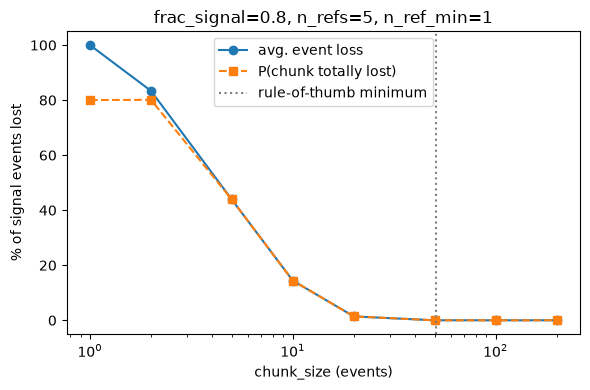

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(chunk_sizes, np.array(avg_loss) * 100, "o-", label="avg. event loss")
ax.plot(chunk_sizes, np.array(p_refless) * 100, "s--", label="P(chunk totally lost)")
ax.axvline(recommended_min, color="gray", linestyle=":", label="rule-of-thumb minimum")
ax.set_xscale("log")
ax.set_xlabel("chunk_size (events)")
ax.set_ylabel("% of signal events lost")
ax.set_title(f"frac_signal={frac_signal}, n_refs={n_refs}, n_ref_min={n_ref_min}")
ax.legend()
fig.tight_layout()

## 5 — Chunk-size and memory-budget advisor

`suggest_chunk_size` picks the largest per-task chunk size that fits a memory
budget, and warns if that's smaller than the rolling-window rule of thumb from
section 4. `ResultStore` decides memory-vs-disk for the *final* result the same way.
Numbers below use a 4000x4000 float32 image, matching the worst-case scenario from
the design discussion.


In [19]:
event_nbytes = 4000 * 4000 * 4  # float32
n_bins_total = 100

for budget_gb in [0.5, 2, 8, 32]:
    cs = rd.suggest_chunk_size(
        event_nbytes=event_nbytes,
        n_bins_total=n_bins_total,
        frac_signal=0.8,
        memory_budget_bytes=budget_gb * 1024**3,
        n_ref_min=1,
    )
    print(f"memory_budget={budget_gb:>5.1f} GB -> chunk_size={cs}")

memory_budget=  0.5 GB -> chunk_size=2
memory_budget=  2.0 GB -> chunk_size=9
memory_budget=  8.0 GB -> chunk_size=39
memory_budget= 32.0 GB -> chunk_size=190


/tmp/ipykernel_84779/91123158.py:5: UserWarning: suggest_chunk_size picked chunk_size=2 to fit the memory budget, but that is below the ~51 (10 x n_ref_min / frac_ref) events typically needed for the rolling reference window to reliably fill within a chunk -- expect non-negligible (possibly whole-chunk) event loss at chunk boundaries. Consider raising memory_budget_bytes, lowering n_ref_min, or accepting the loss.
  cs = rd.suggest_chunk_size(
/tmp/ipykernel_84779/91123158.py:5: UserWarning: suggest_chunk_size picked chunk_size=9 to fit the memory budget, but that is below the ~51 (10 x n_ref_min / frac_ref) events typically needed for the rolling reference window to reliably fill within a chunk -- expect non-negligible (possibly whole-chunk) event loss at chunk boundaries. Consider raising memory_budget_bytes, lowering n_ref_min, or accepting the loss.
  cs = rd.suggest_chunk_size(
/tmp/ipykernel_84779/91123158.py:5: UserWarning: suggest_chunk_size picked chunk_size=39 to fit the memo

In [11]:
# ResultStore backend auto-selection for a few binning scenarios
for n_bins, shape, dtype in [
    (50, (4000, 4000), np.float32),
    (1000, (4000, 4000), np.float32),
    (10000, (4000, 4000), np.float32),
]:
    nbytes = rd.estimate_result_bytes(n_bins, shape, dtype)
    store = rd.ResultStore(n_bins, shape, dtype=dtype, memory_budget_bytes=4 * 1024**3)
    print(f"n_bins={n_bins:>6}  dense size={nbytes/1e9:8.2f} GB  -> backend={store.backend}")

ResultStore: backend=memory (dense result would be 3.20 GB, memory_budget_bytes=4.29 GB)
n_bins=    50  dense size=    3.20 GB  -> backend=memory
ResultStore: backend=disk (dense result would be 64.00 GB, memory_budget_bytes=4.29 GB)
n_bins=  1000  dense size=   64.00 GB  -> backend=disk
ResultStore: backend=disk (dense result would be 640.00 GB, memory_budget_bytes=4.29 GB)
n_bins= 10000  dense size=  640.00 GB  -> backend=disk


## 6 — Timing at increasing scale

Bump these toward your real data size to get a feel for wall-clock time on your
hardware. Watch worker memory (e.g. the dask dashboard) while this runs, especially
past the point where `result_backend` switches to `"disk"`.


In [12]:
for len_all, event_shape in [(2_000, (200, 200)), (10_000, (200, 200)), (10_000, (500, 500))]:
    t0 = time.time()
    rd._demo(
        len_all=len_all,
        event_shape=event_shape,
        n_bins_total=50,
        chunk_size="auto",
        memory_budget_bytes=2 * 1024**3,
    )
    print(f"len_all={len_all}, event_shape={event_shape} -> wall time {time.time()-t0:.2f}s\n")

suggest_chunk_size picked chunk_size=3305
ResultStore: backend=memory (dense result would be 0.02 GB, memory_budget_bytes=2.15 GB)


compute took 0.63s -> (50, 200, 200)
len_all=2000, event_shape=(200, 200) -> wall time 0.69s

suggest_chunk_size picked chunk_size=3305
ResultStore: backend=memory (dense result would be 0.02 GB, memory_budget_bytes=2.15 GB)


compute took 4.11s -> (50, 200, 200)
len_all=10000, event_shape=(200, 200) -> wall time 4.14s

suggest_chunk_size picked chunk_size=486
ResultStore: backend=memory (dense result would be 0.10 GB, memory_budget_bytes=2.15 GB)


compute took 27.76s -> (50, 500, 500)
len_all=10000, event_shape=(500, 500) -> wall time 27.84s



## Next steps

- Section 4's loss numbers only manage the *symptom* (pick a chunk size where loss
  is tolerable). If exact rolling continuity across chunk boundaries turns out to be
  necessary, the two candidate designs noted in `rollin_dev.py` are a small
  sequential state-carry pass between chunks, or `dask.array.overlap.map_overlap`.
- ~~The reference frames collected in `bin_running_ref` were gathered but not
  applied~~ -- resolved: see section 2 above (`cmp_type`/`ref_weighted`).
